# Zadanie 1. Pobranie i wstępne przetwarzanie zbioru danych

> Cel: Przygotowanie zbioru danych do klasyfikacji sygnałów audio słów

In [2]:
import librosa
import IPython.display as ipd
import scipy
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
train_audio_path = "../data/"

In [3]:
samples, sample_rate = librosa.load(train_audio_path + "yes/0a7c2a8d_nohash_0.wav", sr=16000)

c:\Users\posze\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify at 0x0000018715393240>
Traceback (most recent call last):
  File "c:\Users\posze\AppData\Local\Programs\Python\Python311\Lib\site-packages\llvmlite\binding\executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):

KeyboardInterrupt: 


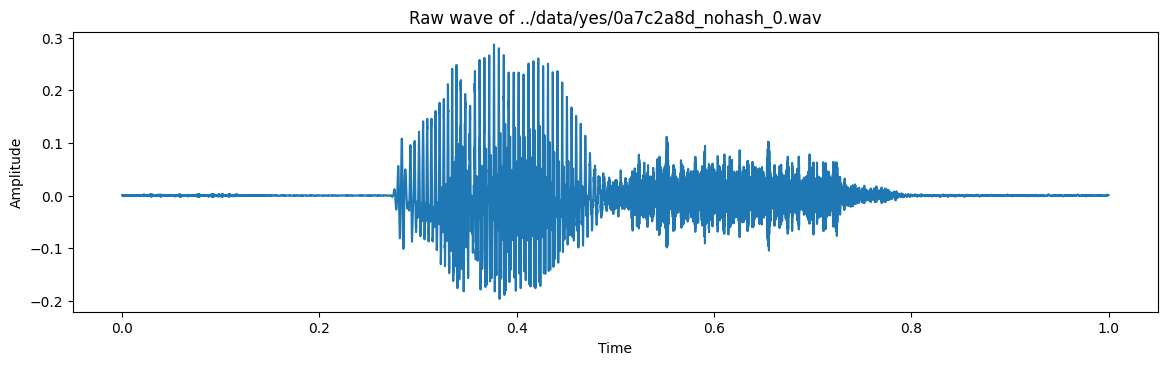

In [ ]:
fig = plt.figure(figsize=(14, 8))
ax1 = fig.add_subplot(2, 1, 1)
ax1.set_title(f"Raw wave of {train_audio_path + 'yes/0a7c2a8d_nohash_0.wav'}")
ax1.set_xlabel("Time")
ax1.set_ylabel("Amplitude")
ax1.plot(np.linspace(0, sample_rate / len(samples), sample_rate), samples)

In [ ]:
ipd.Audio(samples, rate=sample_rate)

In [ ]:
samples = librosa.resample(np.asarray(samples, dtype=np.float32), orig_sr=sample_rate, target_sr=8000)
ipd.Audio(samples, rate=8000)

Wybrane słowa: 
- marvin
- go
- left
- one
- happy 
- dog
- bird
- stop
- on 
- tree

In [4]:
words = [
    "marvin",
    "go",
    "left",
    "one",
    "happy",
    "dog",
    "bird",
    "stop",
    "on",
    "tree"
]

In [ ]:
for word in words:
    path = os.path.join(train_audio_path, word)
    print(f"Number of samples in {word} is {len(os.listdir(path))}")


Number of samples in marvin is 1746
Number of samples in go is 2372
Number of samples in left is 2353
Number of samples in one is 2370
Number of samples in happy is 1742
Number of samples in dog is 1746
Number of samples in bird is 1731
Number of samples in stop is 2380
Number of samples in on is 2367
Number of samples in tree is 1733


In [ ]:
for word in words:
    files = os.listdir(os.path.join(train_audio_path, word))
    
    word_mean_length = 0

    for file in files:
        path = os.path.join(train_audio_path, word, file)
        samples, sample_rate = librosa.load(path, sr=16000)
        word_mean_length += len(samples) / sample_rate
    
    word_mean_length /= len(files)
    print(f"Mean length of samples in {word} is {word_mean_length:.2f} seconds")
        

Mean length of samples in marvin is 0.99 seconds
Mean length of samples in go is 0.98 seconds
Mean length of samples in left is 0.99 seconds
Mean length of samples in one is 0.98 seconds
Mean length of samples in happy is 0.98 seconds
Mean length of samples in dog is 0.98 seconds
Mean length of samples in bird is 0.98 seconds
Mean length of samples in stop is 0.99 seconds
Mean length of samples in on is 0.98 seconds
Mean length of samples in tree is 0.98 seconds


In [ ]:
dataset: dict[str, list[tuple]] = {}

for word in words:
    files = os.listdir(os.path.join(train_audio_path, word))
    dataset[word]: list[tuple] = []

    for file in files:
        path = os.path.join(train_audio_path, word, file)

        samples, sample_rate = librosa.load(path, sr=16000)
        
        if len(samples) / sample_rate == 1.0:
            samples = librosa.resample(np.asarray(samples, dtype=np.float32), orig_sr=sample_rate, target_sr=8000)
            dataset[word].append((samples, 8000))


In [ ]:
# save dataset to files 

for word in words:
    for i, (samples, sample_rate) in enumerate(dataset[word]):
        path = os.path.join("../processed_data", word)
        os.makedirs(path, exist_ok=True)
        scipy.io.wavfile.write(os.path.join(path, f"{word}_{i}.wav"), sample_rate, samples)

In [5]:
import torch
from torch.utils.data import Dataset, WeightedRandomSampler, DataLoader
from sklearn.model_selection import train_test_split


In [6]:
class AudioDataset(Dataset):
    """
    Dataset for loading audio samples 
    Requirements:
    - Audio needs to be resampled to 8000 Hz
    """

    def __init__(self, audio_dirs: list[str]):
        self.audio_dirs = audio_dirs
        self.data: list[tuple] = []
        self.labels: list[int] = []

        self.class_to_idx = { 
            audio_dir.split("\\")[-1]: i for i, audio_dir in enumerate(audio_dirs)
        }

        # Podaje ścieżki do katalogów z audio
        # Np. ["../processed_data/marvin", "../processed_data/go"]

        for audio_dir in audio_dirs:
            label = audio_dir.split("\\")[-1]

            for file in os.listdir(audio_dir):
                path = os.path.join(audio_dir, file)
                samples, sample_rate = librosa.load(path, sr=8000)
                self.data.append((samples))
                self.labels.append(self.class_to_idx[label])

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.int64)

        return x, y



In [7]:
def create_dataloaders(audio_dirs: list[str], train_val_test_split: tuple, batch_size: int = 32, num_workers: int = 4):
    train_ratio = train_val_test_split[0]
    val_ratio = train_val_test_split[1]
    test_ratio = train_val_test_split[2]

    dataset = AudioDataset(audio_dirs)
    
    # Dobranie rozmiaru zbiorów
    x_train, x_val_test, y_train, y_val_test = train_test_split(
        dataset.data, dataset.labels, test_size=(1 - train_ratio), stratify=dataset.labels
    )

    # val% + test% - 100%
    # test% - x
    # x = test% * 1 / (val% + test%)

    adj_test = test_ratio / (test_ratio + val_ratio)

    x_val, x_test, y_val, y_test = train_test_split(
        x_val_test, y_val_test, test_size=adj_test, stratify=y_val_test
    )

    class_counts_train = {label: y_train.count(label) for label in set(y_train)}
    weight_train = [1.0 / class_counts_train[label] for label in y_train]

    train_dataloader = DataLoader(
        list(zip(x_train, y_train)), batch_size=batch_size, sampler=WeightedRandomSampler(weight_train, num_samples=len(weight_train)), num_workers=num_workers
    )

    val_dataloader = DataLoader(
        list(zip(x_val, y_val)), batch_size=batch_size, shuffle=False, num_workers=num_workers
    )

    test_dataloader = DataLoader(
        list(zip(x_test, y_test)), batch_size=batch_size, shuffle=False, num_workers=num_workers
    )

    return train_dataloader, val_dataloader, test_dataloader

In [ ]:
train_dataloader, val_dataloader, test_dataloader = create_dataloaders(
    audio_dirs=[os.path.join("../processed_data", word) for word in words],
    train_val_test_split=(0.7, 0.15, 0.15),
    batch_size=64,
    num_workers=4
)

In [ ]:
sample = train_dataloader.dataset[0]
sample

(array([1.2602337e-04, 5.2689738e-04, 9.6326624e-04, ..., 7.6847500e-05,
        8.5799035e-04, 6.8407238e-04], shape=(8000,), dtype=float32),
 1)

In [ ]:
dataset = AudioDataset(audio_dirs=[os.path.join("../processed_data", word) for word in words])

print(f"Sample class is {words[sample[1]]}")

Sample class is go


---

# Zadanie 2: Sieć konwolucyjna do klasyfikacji nagrań

> Cel: Implementacja i trening sieci konwolucyjnej do klasyfikacji wybranych nagrań

In [8]:
import torch
import torch.nn as nn

from sklearn.model_selection import StratifiedKFold

In [9]:
class AudioClassifier(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        # Input (batch_size, 1, 8000)
        # Warstwa 1
        self.block1 = nn.Sequential(
            nn.Conv1d(
                in_channels=1, 
                out_channels=8, 
                kernel_size=13,
                padding='valid'
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3),
            nn.Dropout(0.3)
        )
        # Output (batch_size, 8, 2662)

        # Warstwa 2 
        self.block2 = nn.Sequential(
            nn.Conv1d(
                in_channels=8, 
                out_channels=16, 
                kernel_size=11,
                padding='valid'
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3),
            nn.Dropout(0.3)
        )
        # Output (batch_size, 16, 884)

        # Warstwa 3
        self.block3 = nn.Sequential(
            nn.Conv1d(
                in_channels=16, 
                out_channels=32, 
                kernel_size=9,
                padding='valid'
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3),
            nn.Dropout(0.3)
        )
        # Output (batch_size, 32, 292)

        # Warstwa 4
        self.block4 = nn.Sequential(
            nn.Conv1d(
                in_channels=32, 
                out_channels=64, 
                kernel_size=7,
                padding='valid'
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3),
            nn.Dropout(0.3)
        )
        # Output (batch_size, 64, 95)

        self.flatten = nn.Flatten()
        # Output (batch_size, 6080)

        self.classifier = nn.Sequential(
            nn.Linear(6080, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self,X):
        X = self.block1(X)
        X = self.block2(X)
        X = self.block3(X)
        X = self.block4(X)
        X = self.flatten(X)
        X = self.classifier(X)

        return X

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True)

dataset = AudioDataset(audio_dirs=[os.path.join("../processed_data", word) for word in words])

train_dataloader, val_dataloader, test_dataloader = create_dataloaders(
    audio_dirs=[os.path.join("../processed_data", word) for word in words],
    train_val_test_split=(0.7, 0.15, 0.15),
    batch_size=64,
    num_workers=4
)

train_val_pairs = list(train_dataloader.dataset) + list(val_dataloader.dataset)

X_tv = [pair[0] for pair in train_val_pairs]
y_tv = [pair[1] for pair in train_val_pairs]

for fold, (train_idx, val_idx) in enumerate(skf.split(X_tv, y_tv)):
    print(f"Fold {fold + 1}")
    model = AudioClassifier(num_classes=len(words))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    train_dataloader_2 = DataLoader(
        [train_val_pairs[i] for i in train_idx],
        batch_size=64,
        shuffle=True,
        num_workers=4
    )

    val_dataloader_2 = DataLoader(
        [train_val_pairs[i] for i in val_idx],
        batch_size=64,
        shuffle=False,
        num_workers=4
    )

    best_fold_val_loss = float("inf")

    for epoch in range(10):
        model.train()
        train_loss = 0.0

        for x_batch, y_batch in train_dataloader_2:
            optimizer.zero_grad()
            yhat = model(x_batch.unsqueeze(1))
            loss = loss_fn(yhat, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() 
        
        train_loss /= len(train_dataloader_2)

        model.eval()
        val_loss = 0.0

        with torch.inference_mode():
            for x_batch, y_batch in val_dataloader_2:
                yhat = model(x_batch.unsqueeze(1))
                loss = loss_fn(yhat, y_batch)
                val_loss += loss.item()
            
        val_loss /= len(val_dataloader_2)

        print(f"Epoch {epoch + 1} - Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

        if val_loss < best_fold_val_loss:
            best_fold_val_loss = val_loss
            torch.save(model.state_dict(), f"../models/best_model_fold_{fold + 1}.pth")

    






c:\Users\posze\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fold 1


KeyboardInterrupt: 